In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('./Data/gurgaon_properties_cleaned_v2.csv')

In [3]:
df.head()

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,emaar palm gardens,sector 83,1.8 Crore,9473.0,Super Built up area 1900(176.52 sq.m.),3,3,3+,9.0,...,1900.0,NaN,NaN,0,0,0,0,0,0,55
1,flat,breez global hill view,sohna road,29.99 Lac,5403.0,Super Built up area 655(60.85 sq.m.)Carpet are...,2,2,2,6.0,...,655.0,NaN,555.0,0,0,0,0,0,0,109
2,flat,ambience creacions,sector 22,4.78 Crore,15469.0,Super Built up area 3090(287.07 sq.m.)Built Up...,3,4,3,7.0,...,3090.0,2500.0,2250.0,0,1,0,0,1,2,111
3,flat,aipl zen residences,sector 70a,1.25 Crore,9904.0,Carpet area: 1262 (117.24 sq.m.),2,2,3,19.0,...,NaN,NaN,1262.0,0,0,0,0,0,0,0
4,flat,sare homes,sector 92,1.18 Crore,5207.0,Carpet area: 2266 (210.52 sq.m.),4,4,3,8.0,...,NaN,NaN,2266.0,0,1,0,0,0,0,108


In [5]:
def convert_to_crore(x):
    if pd.isnull(x):
        return None
    
    x = str(x).lower().strip()
    
    if 'crore' in x:
        return float(x.replace('crore', '').strip())
    
    elif 'lac' in x or 'lakh' in x:
        val = float(x.replace('lacs', '').replace('lac', '').replace('lakh', '').strip())
        return val / 100  # convert to crore
    
    else:
        return None  # or handle differently if needed

In [6]:
df['price_crore'] = df['price'].apply(convert_to_crore)

In [9]:
df['price']

0       1.80
1       0.30
2       4.78
3       1.25
4       1.18
        ... 
3811    7.00
3812    3.60
3813    1.08
3814    0.99
3815    1.05
Name: price, Length: 3816, dtype: float64

In [8]:
import re

def convert_to_crore(x):
    if pd.isnull(x):
        return None
    
    x = str(x).lower()
    num = re.findall(r'\d+\.?\d*', x)
    
    if not num:
        return None
    
    val = float(num[0])
    
    if 'crore' in x:
        return round(val, 2)
    elif 'lac' in x or 'lakh' in x:
        return round(val / 100, 2)
    else:
        return None

# Replace the original column
df['price'] = df['price'].apply(convert_to_crore)

In [10]:
df.duplicated().sum()

np.int64(127)

In [11]:
df.drop_duplicates(inplace=True)

<Axes: xlabel='property_type'>

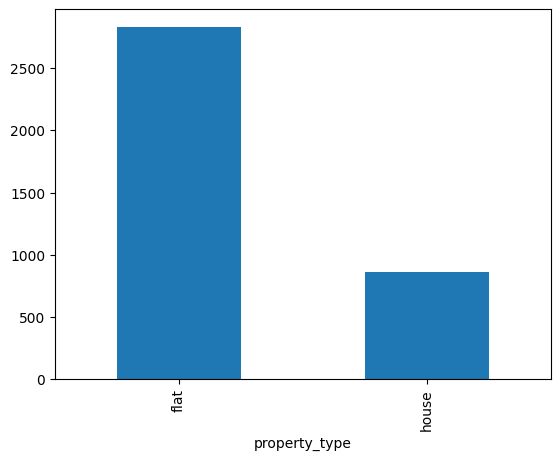

In [12]:
df['property_type'].value_counts().plot(kind='bar',)

In [13]:
df['society'].value_counts().shape

(677,)

In [14]:
df['society'].value_counts()

society
tulip violet                                  75
ss the leaf                                   73
dlf new town heights                          42
shapoorji pallonji joyville gurugram          42
signature global park                         35
                                              ..
ganpati apartment  2, laxman vihar phase 1     1
kanchanjanga tower                             1
madan puri                                     1
signature global orchard avenue 2              1
shreeram apartment ii                          1
Name: count, Length: 677, dtype: int64

In [15]:
df[df['society'] != 'independent']['society'].value_counts(normalize=True).cumsum().head(75)

society
tulip violet                            0.023423
ss the leaf                             0.046221
dlf new town heights                    0.059338
shapoorji pallonji joyville gurugram    0.072455
signature global park                   0.083385
                                          ...   
indiabulls enigma                       0.489382
ansal heights 86                        0.493442
ats kocoon                              0.497502
unitech uniworld resorts                0.501249
ireo the corridors                      0.504997
Name: proportion, Length: 75, dtype: float64

In [16]:
society_counts = df['society'].value_counts()

# Frequency distribution for societies
frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
frequency_bins

{'Very High (>100)': np.int64(0),
 'High (50-100)': np.int64(2),
 'Average (10-49)': np.int64(92),
 'Low (2-9)': np.int64(277),
 'Very Low (1)': np.int64(306)}

<Axes: xlabel='society'>

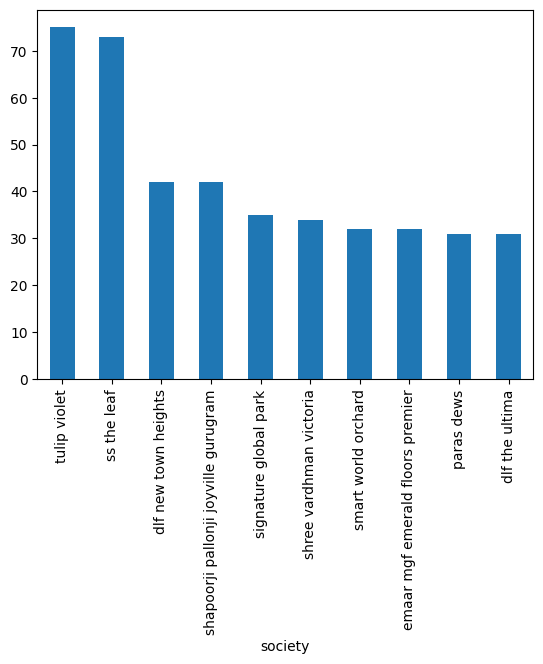

In [17]:
# top 10 socities
df[df['society'] != 'independent']['society'].value_counts().head(10).plot(kind='bar')

In [18]:
df['society'].isnull().sum()

np.int64(487)

In [19]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,...,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,price_crore
11,house,NaN,sector 12,NaN,6034.0,Plot area 1160(107.77 sq.m.),3,3,0,1.0,...,1160.0,NaN,0,0,0,0,0,0,23,NaN
12,house,NaN,sector 55,NaN,27741.0,Plot area 300(250.84 sq.m.),12,12,3+,4.0,...,300.0,NaN,1,1,0,1,0,1,49,NaN
14,house,NaN,sector 6,NaN,13889.0,Plot area 40(33.45 sq.m.),5,3,3,3.0,...,40.0,NaN,0,0,0,0,0,0,0,NaN
21,house,NaN,sector 25,NaN,38760.0,Plot area 215(179.77 sq.m.),9,9,3,4.0,...,215.0,NaN,1,0,1,1,0,1,84,NaN
24,house,NaN,sector 12,NaN,14184.0,Plot area 846(78.6 sq.m.)Built Up area: 846 sq...,4,4,2,2.0,...,846.0,NaN,0,0,0,1,0,1,7,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3733,house,NaN,sector 51,NaN,25000.0,Plot area 100(83.61 sq.m.),6,3,3+,3.0,...,100.0,NaN,0,0,0,0,0,0,54,NaN
3734,house,NaN,sector 31,NaN,22429.0,Plot area 161(134.62 sq.m.),4,4,3+,3.0,...,161.0,NaN,1,1,1,1,0,1,29,NaN
3749,house,NaN,sector 3,NaN,10288.0,Plot area 162(135.45 sq.m.)Built Up area: 210 ...,3,3,0,NaN,...,210.0,NaN,0,0,0,0,0,0,0,NaN
3766,house,NaN,sector 5,NaN,5000.0,Built Up area: 3000 (278.71 sq.m.),6,1,0,1.0,...,3000.0,NaN,0,0,0,0,0,0,0,NaN


#### Observations

- Around 13% properties comes under independent tag.
- There are 675 societies. 
- The top 75 societies have 50 percent of the preperties and the rest 50 percent of the properties come under the remaining 600 societies
    - Very High (>100): Only 1 society has more than 100 listings.
    - High (50-100): 2 societies have between 50 to 100 listings.
    - Average (10-49): 92 societies fall in this range with 10 to 49 listings each.
    - Low (2-9): 273 societies have between 2 to 9 listings.
    - Very Low (1): A significant number, 308 societies, have only 1 listing.
- 1 missing value

In [20]:
df['sector'].value_counts().shape

(113,)

<Axes: xlabel='sector'>

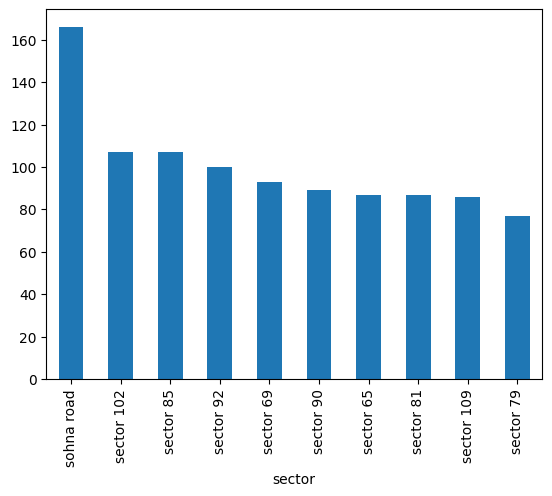

In [21]:

df['sector'].value_counts().head(10).plot(kind='bar')

In [22]:
sector_counts = df['sector'].value_counts()

sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

sector_frequency_bins

{'Very High (>100)': np.int64(3),
 'High (50-100)': np.int64(25),
 'Average (10-49)': np.int64(62),
 'Low (2-9)': np.int64(22),
 'Very Low (1)': np.int64(1)}

#### Observations

- There are a total of 104 unique sectors in the dataset.
- Frequency distribution of sectors:
    - Very High (>100): 3 sectors have more than 100 listings.
    - High (50-100): 25 sectors have between 50 to 100 listings.
    - Average (10-49): A majority, 60 sectors, fall in this range with 10 to 49 listings each.
    - Low (2-9): 16 sectors have between 2 to 9 listings.
    - Very Low (1): Interestingly, there are no sectors with only 1 listing.

In [23]:
df['price'].isnull().sum()

np.int64(870)

In [24]:
df['price'].describe()

count    2819.000000
mean        1.712863
std         1.388163
min         0.160000
25%         0.900000
50%         1.380000
75%         2.050000
max        15.000000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

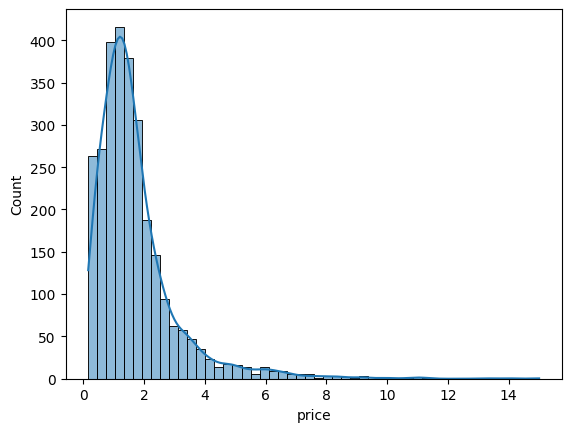

In [25]:
sns.histplot(df['price'], kde=True, bins=50)

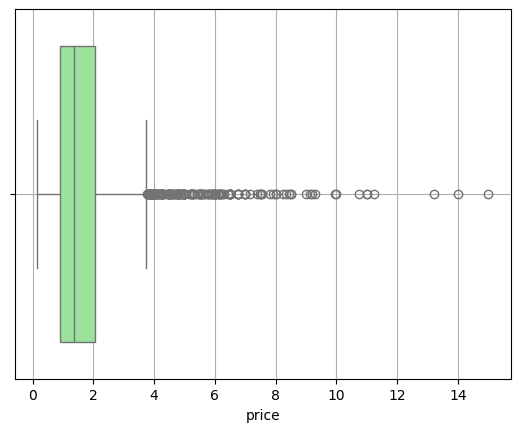

In [26]:
sns.boxplot(x=df['price'], color='lightgreen')
plt.grid()

In [27]:
skewness = df['price'].skew()
kurtosis = df['price'].kurt()

print(skewness,kurtosis)

2.9098082480728666 13.939937234577066


In [28]:
quantiles = df['price'].quantile([0.01, 0.05, 0.95, 0.99])

quantiles

0.01    0.24
0.05    0.35
0.95    4.25
0.99    7.00
Name: price, dtype: float64

In [29]:
Q1 = df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']
IQR = Q3 - Q1

IQR

np.float64(1.15)

In [30]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-0.8249999999999998 3.7749999999999995


In [31]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outliers.shape

(188, 24)

In [32]:
outliers['price'].describe()

count    188.000000
mean       5.651277
std        1.928272
min        3.780000
25%        4.250000
50%        5.000000
75%        6.262500
max       15.000000
Name: price, dtype: float64

<Axes: xlabel='price'>

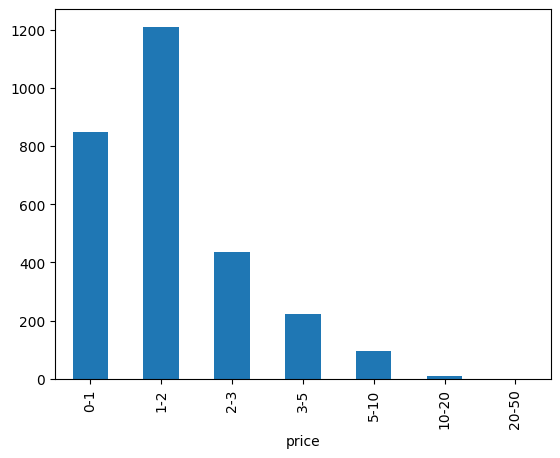

In [33]:
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df['price'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind='bar')

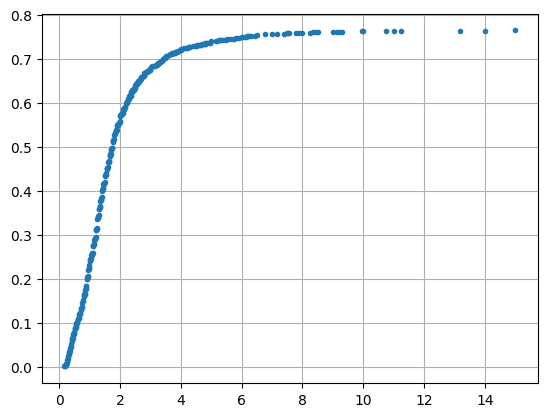

In [34]:
ecdf = df['price'].value_counts().sort_index().cumsum() / len(df['price'])
plt.plot(ecdf.index, ecdf, marker='.', linestyle='none')
plt.grid()

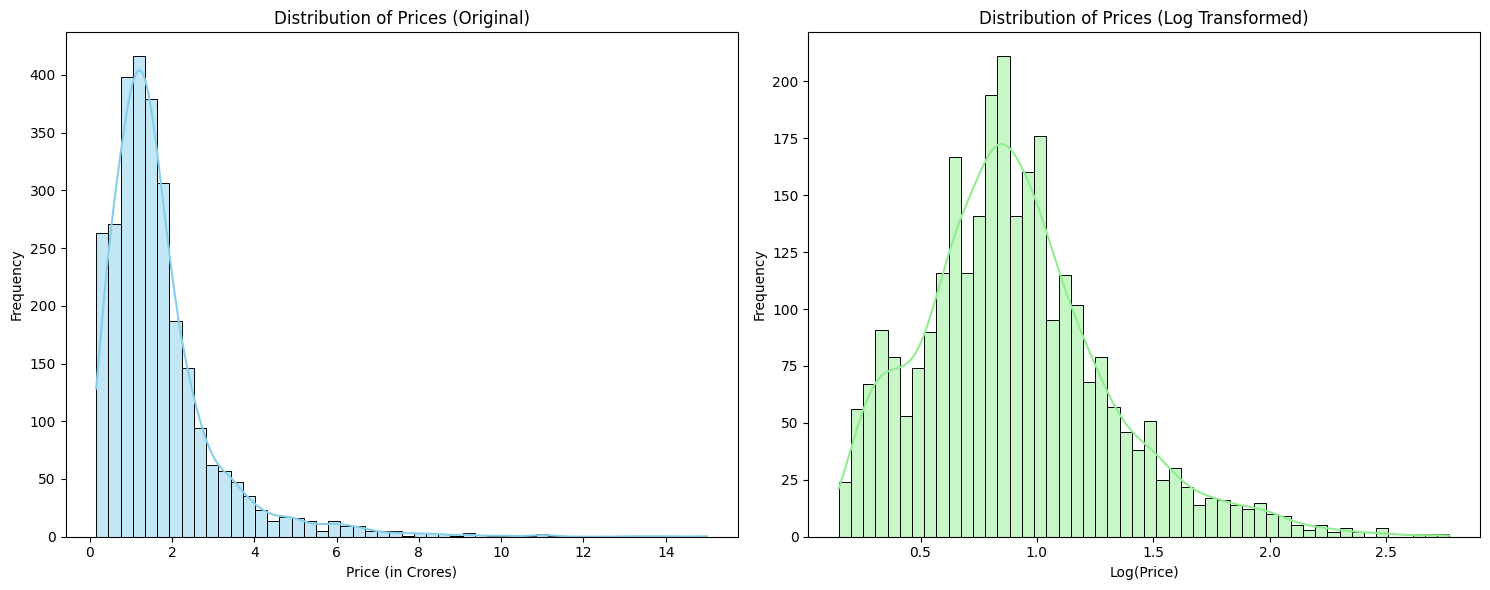

In [35]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [36]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

0.7859302165882981 1.0768271997344616


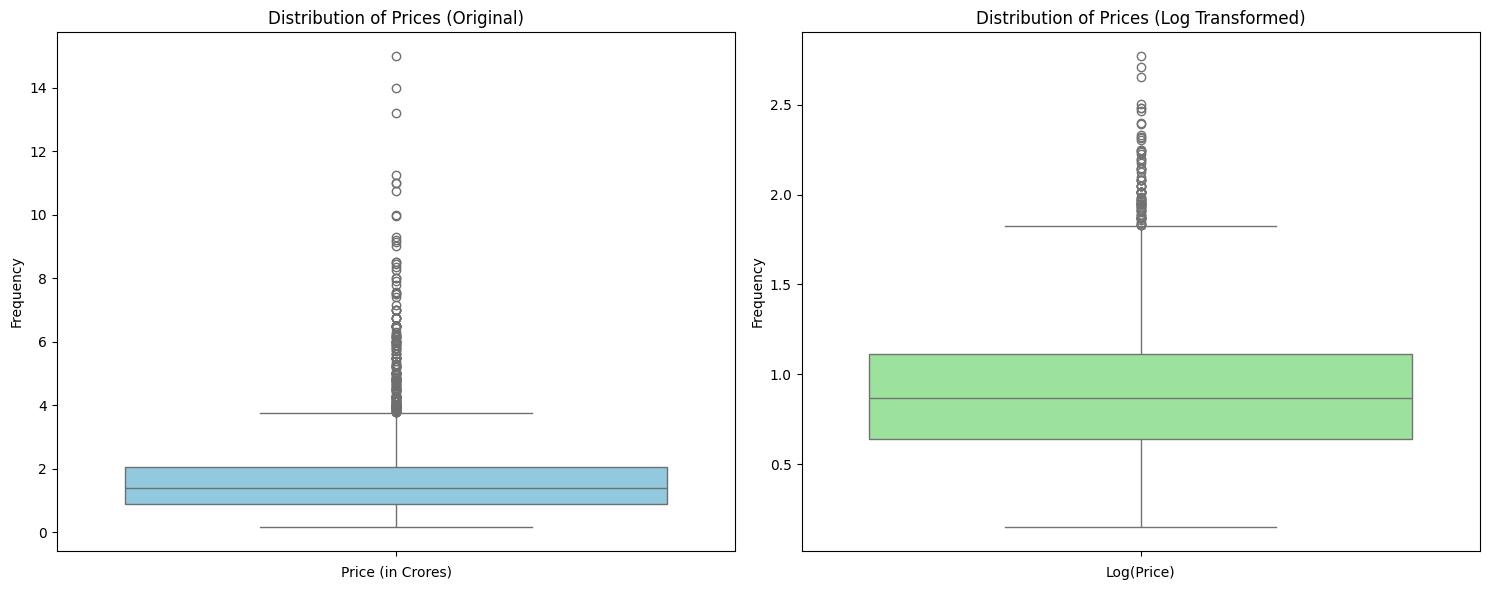

In [37]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(df['price'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(np.log1p(df['price']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [38]:
df['price_per_sqft'].isnull().sum()

np.int64(27)

In [39]:
df['price_per_sqft'].describe()

count      3662.000000
mean      13889.168760
std       23204.227522
min           4.000000
25%        6815.750000
50%        9018.000000
75%       13877.250000
max      600000.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

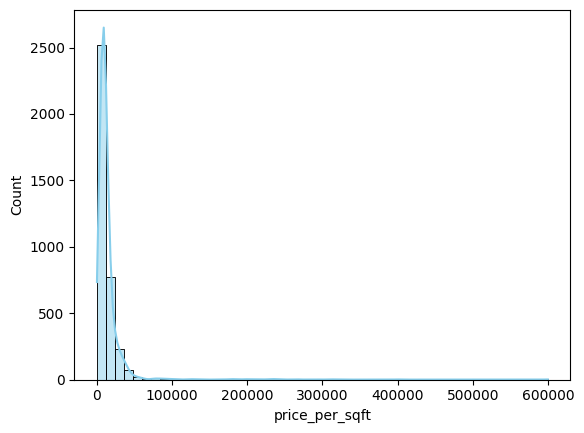

In [40]:
sns.histplot(df['price_per_sqft'], bins=50, color='skyblue', kde=True)

<Axes: ylabel='price_per_sqft'>

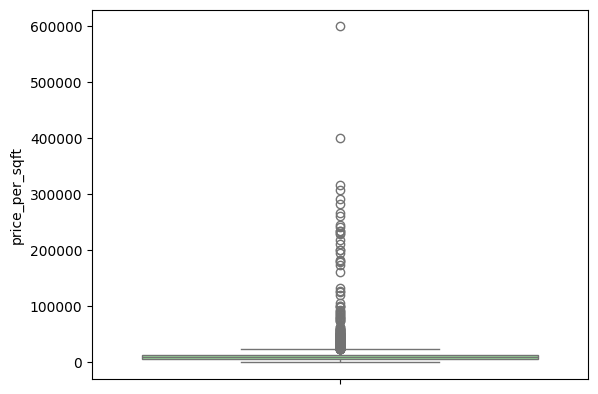

In [41]:
sns.boxplot(df['price_per_sqft'], color='lightgreen')

In [42]:
df['bedRoom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bedRoom'>

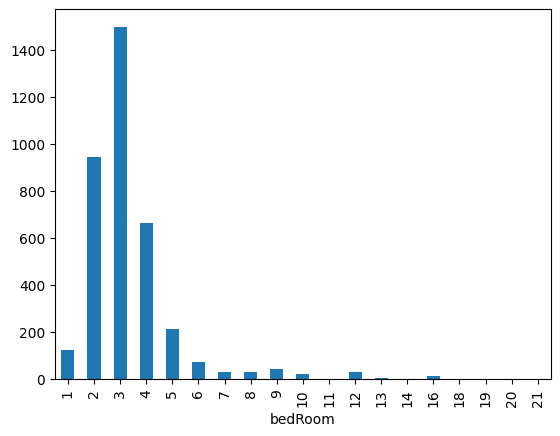

In [43]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

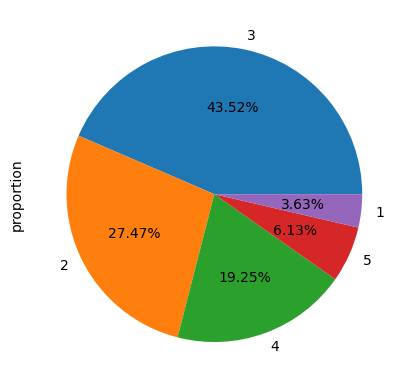

In [44]:
df['bedRoom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [45]:
df['bathroom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bathroom'>

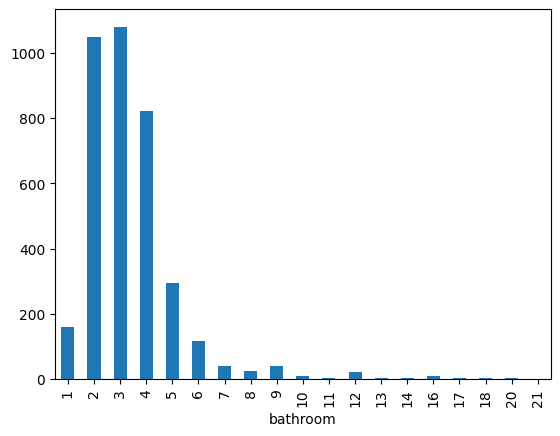

In [46]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

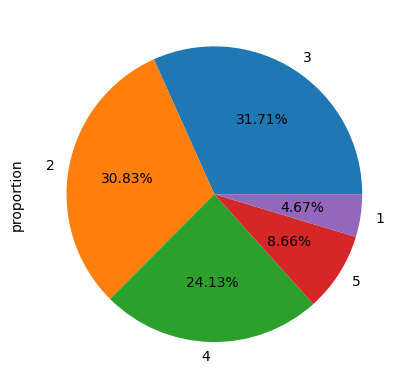

In [47]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [48]:
df['balcony'].isnull().sum()

np.int64(0)

<Axes: xlabel='balcony'>

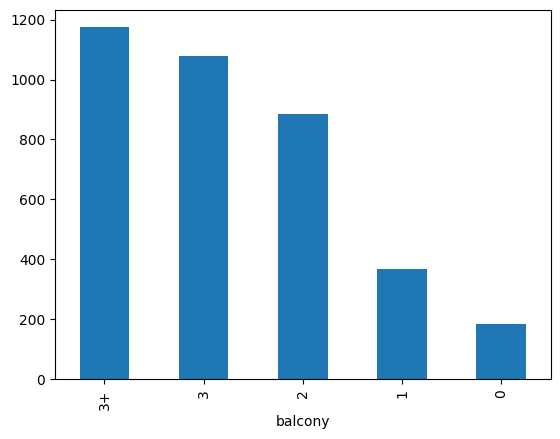

In [49]:
df['balcony'].value_counts().plot(kind='bar')

<Axes: ylabel='proportion'>

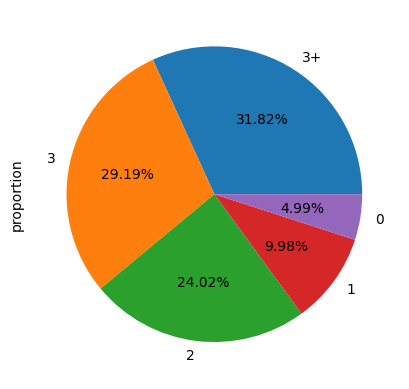

In [50]:
df['balcony'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [51]:
df.iloc[:,10:].head()

,facing,agePossession,area,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,price_crore
0,South,1 to 5 Year Old,NaN,1900.0,NaN,NaN,0,0,0,0,0,0,55,1.8000
1,North-East,0 to 1 Year Old,NaN,655.0,NaN,555.0,0,0,0,0,0,0,109,0.2999
2,West,1 to 5 Year Old,NaN,3090.0,2500.0,2250.0,0,1,0,0,1,2,111,4.7800
3,NaN,undefined,NaN,NaN,NaN,1262.0,0,0,0,0,0,0,0,1.2500
4,North,1 to 5 Year Old,NaN,NaN,NaN,2266.0,0,1,0,0,0,0,108,1.1800


In [52]:
df['floorNum'].isnull().sum()

np.int64(19)

In [53]:
df['floorNum'].describe()

count    3670.000000
mean        6.805177
std         6.015010
min         0.000000
25%         2.000000
50%         5.000000
75%        10.000000
max        51.000000
Name: floorNum, dtype: float64

<Axes: xlabel='floorNum'>

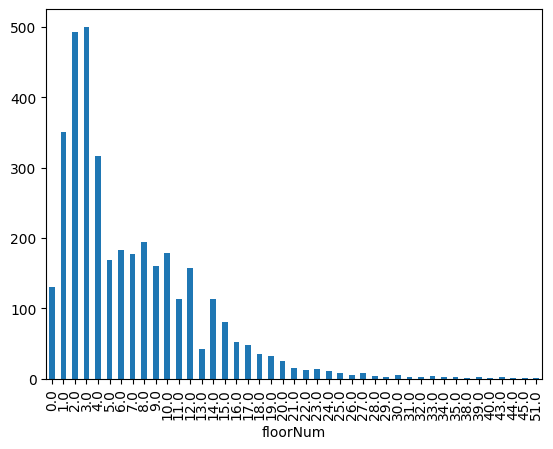

In [54]:
df['floorNum'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='floorNum'>

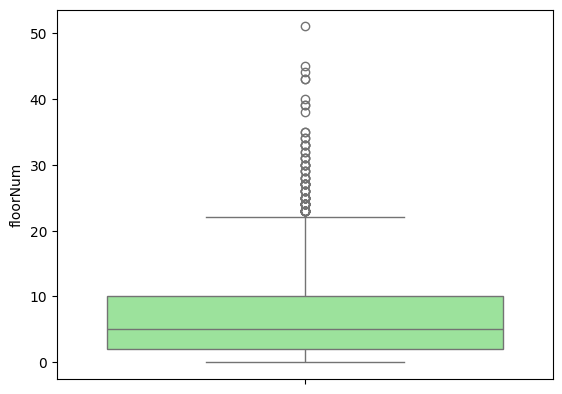

In [55]:
sns.boxplot(df['floorNum'], color='lightgreen')

In [56]:
df['facing'].isnull().sum()

np.int64(1051)

In [57]:
df['facing'].fillna('NA',inplace=True)

C:\Users\kael7\AppData\Local\Temp\ipykernel_15300\3692945726.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['facing'].fillna('NA',inplace=True)


In [58]:
df['facing'].value_counts()

facing
NA            1051
East           626
North-East     624
North          389
West           249
South          231
North-West     193
South-East     173
South-West     153
Name: count, dtype: int64

In [59]:
df['agePossession'].isnull().sum()

np.int64(1)

In [60]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1647
5 to 10 Year Old       564
0 to 1 Year Old        504
undefined              310
10+ Year Old           303
Under Construction      91
Within 6 months         67
Within 3 months         23
Dec 2023                20
By 2023                 16
By 2024                 16
Dec 2024                15
Mar 2024                12
Dec 2025                 7
Jun 2024                 7
Jan 2024                 7
Oct 2024                 6
Aug 2023                 6
Aug 2024                 5
Nov 2023                 5
Oct 2023                 4
By 2025                  4
Sep 2023                 4
Feb 2024                 3
May 2024                 3
Jan 2025                 3
Nov 2024                 3
Jul 2024                 3
Sep 2025                 2
Apr 2026                 2
Mar 2025                 2
Aug 2025                 2
Jun 2027                 2
Jul 2027                 2
Jan 2026                 2
Dec 2026                 2
Jul 2025      

In [61]:
df['super_built_up_area'].isnull().sum()

np.int64(1811)

<Axes: xlabel='super_built_up_area', ylabel='Count'>

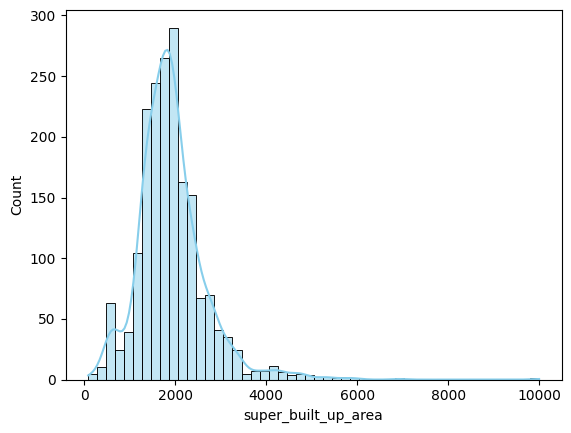

In [62]:
sns.histplot(df['super_built_up_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: ylabel='super_built_up_area'>

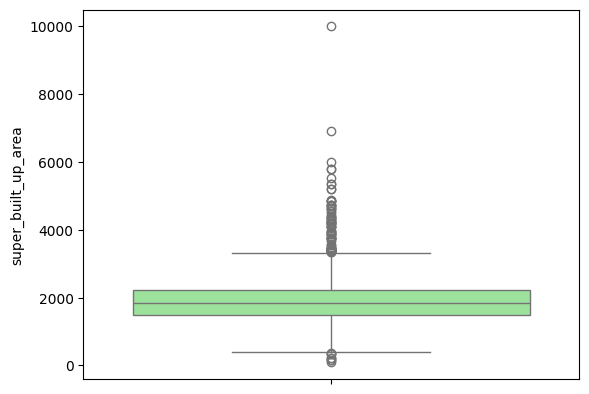

In [63]:
sns.boxplot(df['super_built_up_area'].dropna(), color='lightgreen')

In [64]:
df['built_up_area'].isnull().sum()

np.int64(1995)

In [65]:
df['built_up_area'].describe()

count      1694.000000
mean       1845.442166
std       17924.541736
min           2.000000
25%         360.000000
50%        1260.500000
75%        1900.000000
max      737147.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

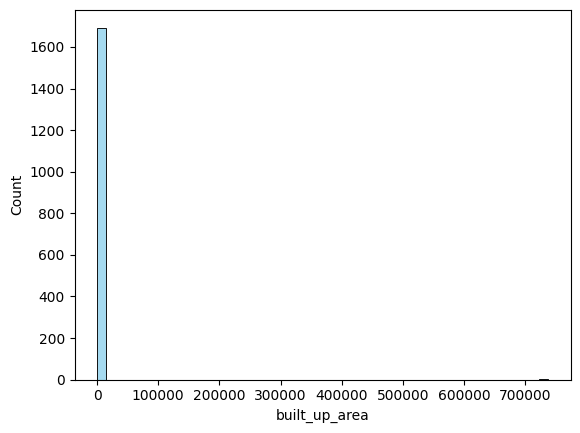

In [66]:
sns.histplot(df['built_up_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='built_up_area'>

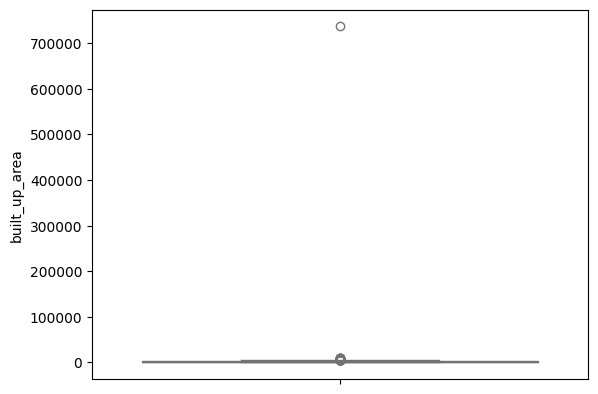

In [67]:
sns.boxplot(df['built_up_area'].dropna(), color='lightgreen')

In [68]:
df['carpet_area'].isnull().sum()

np.int64(1811)

In [69]:
df['carpet_area'].describe()

count      1878.000000
mean       2525.997358
std       22763.596809
min          15.000000
25%         835.470000
50%        1300.000000
75%        1788.750000
max      607936.000000
Name: carpet_area, dtype: float64

<Axes: xlabel='carpet_area', ylabel='Count'>

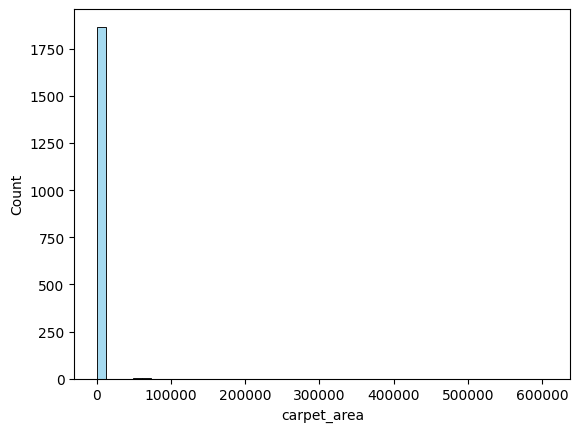

In [70]:
sns.histplot(df['carpet_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='carpet_area'>

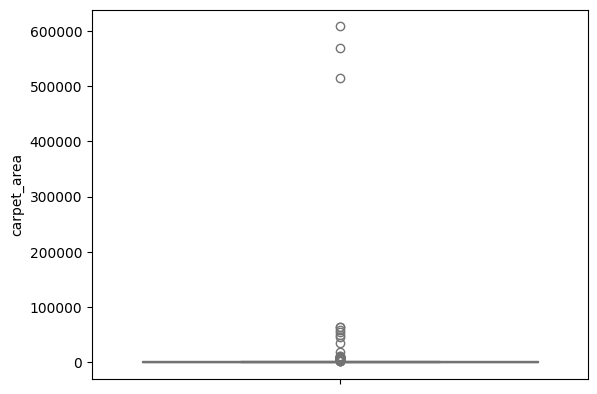

In [71]:
sns.boxplot(df['carpet_area'].dropna(), color='lightgreen')

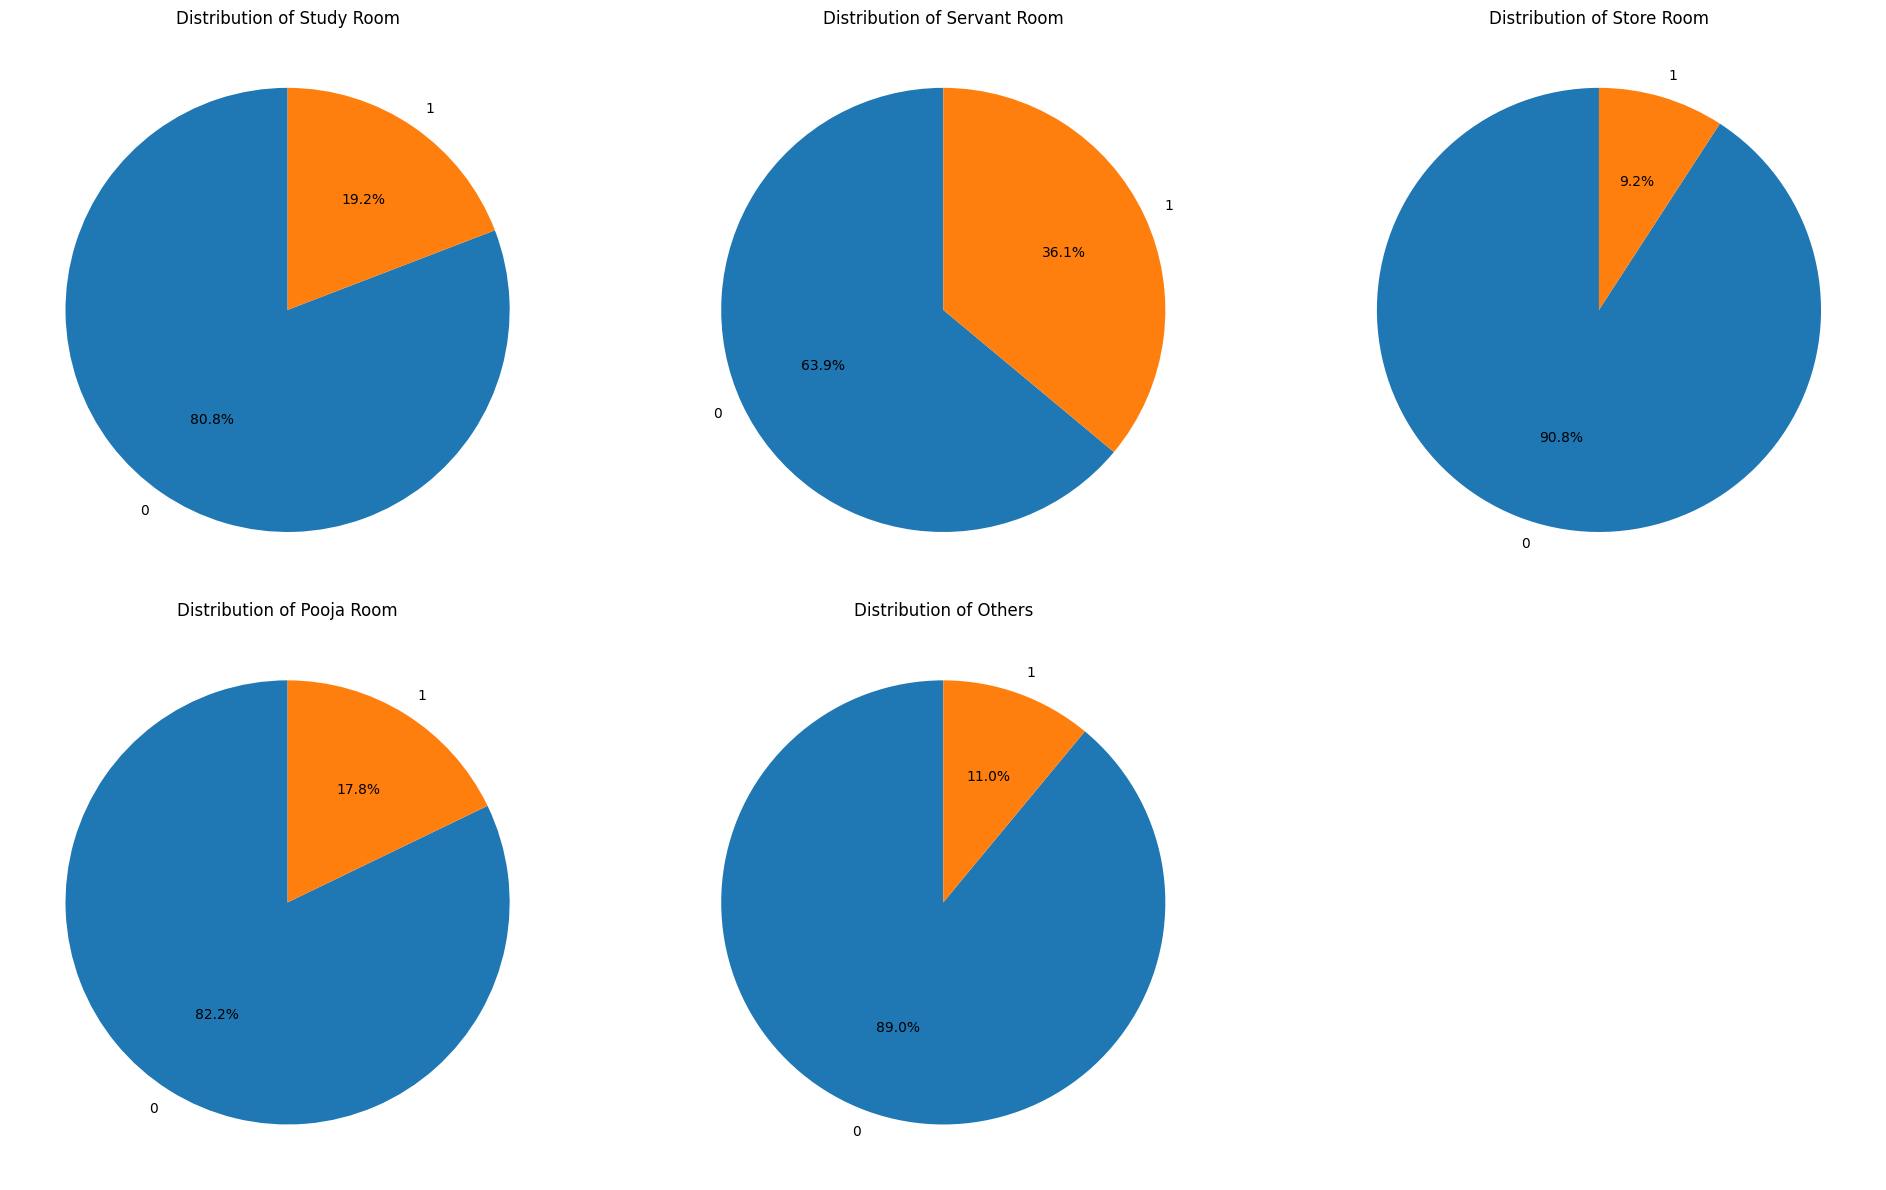

In [72]:
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

In [73]:
df['furnishing_type'].value_counts()

furnishing_type
0    2416
1    1061
2     212
Name: count, dtype: int64

<Axes: ylabel='count'>

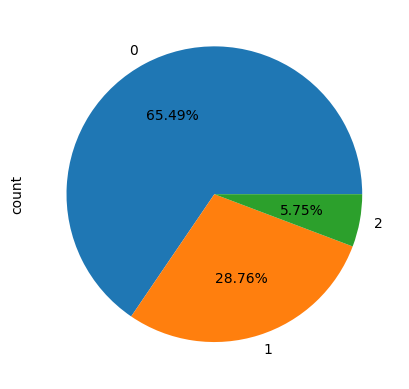

In [74]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [75]:
df['luxury_score'].isnull().sum()

np.int64(0)

In [76]:
df['luxury_score'].describe()

count    3689.000000
mean       71.370832
std        53.065176
min         0.000000
25%        31.000000
50%        59.000000
75%       110.000000
max       174.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

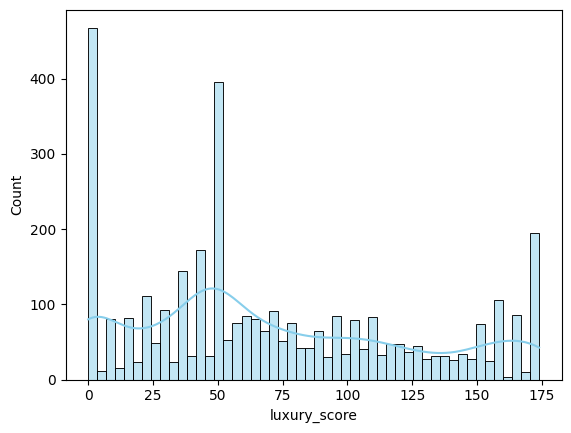

In [77]:
sns.histplot(df['luxury_score'], bins=50, color='skyblue', kde=True)

<Axes: ylabel='luxury_score'>

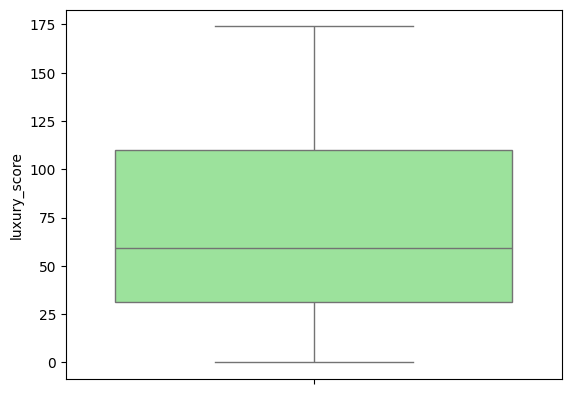

In [78]:
sns.boxplot(df['luxury_score'], color='lightgreen')